지정된 데이터를 이용하여 부류 모델을 만들고 코드를 구조화 하시오

1. 데이터 1 The Oxford-IIIT Pet Dataset.
2. 데이터 2 ISIC2018 Challenge Task1 Data (Segmentation).
3. 필수 구축 구조
    - 데이터 특성을 고려한 커스텀 데이터셋 클래스
    - 데이터 로더
    - 데이터 전처리기
    - 모델 클래스
    - 학습 중간 시작점
    - 결과를 이용한 데이터 분할 결과와 저장(가능한 인원 진행)
4. 모델 성능은 데이터별 1명씩 선정

In [1]:
import os
from pathlib import Path
from PIL import Image
import torch.nn as nn

import numpy as np

import torch
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import functional as TF
import time
import random

In [2]:
DATA_ROOT='../data/isic2018-challenge-task1-data-segmentation'
BATCH_SIZE=8
NUM_WORERS=4
EPOCHS=5
LR=0.005
MOMENTUM=0.9
WEIGHT_DECAY=0.0001

IMG_SIZE=512
N_CLASSES=2
IGNORE_INDEX=255

In [3]:
def make_transform(train):
    def _tfm(img,mask):
        img= TF.resize(img,(IMG_SIZE,IMG_SIZE))
        mask= TF.resize(mask,(IMG_SIZE,IMG_SIZE),interpolation=TF.InterpolationMode.NEAREST)
        if train and torch.rand(1)<0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485,0.456,0.406], [0.229,0.224,0.225])
        mask_ck = np.array(mask)
        if mask_ck.ndim==3:
            mask_ck=(mask_ck>0).any(axis=2).astype(np.uint8)
        mask=torch.as_tensor(mask_ck,dtype=torch.long)
        return img,mask
    return _tfm
class PetTrimapDataset(Dataset):
    def __init__(self, root, file_list, tf=None):
        self.root = Path(root)
        self.files = file_list
        self.tf = tf
        self.img_dir = self.root / 'ISIC2018_Task1-2_Training_Input'
        self.seg_dir = self.root / 'ISIC2018_Task1_Training_GroundTruth'

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]
        img_path = self.img_dir / filename
        file_stem = Path(filename).stem
        mask_filename = f"{file_stem}_segmentation.png"
        mask_path = self.seg_dir / mask_filename

        img = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path)

        mask_np = np.array(mask)
        mask_np[mask_np == 2] = 0
        mask_np[mask_np == 3] = 0
        mask = Image.fromarray(mask_np, mode='L')

        if self.tf:
            img, mask = self.tf(img, mask)
        return img, mask

def get_loaders_from_folder(root, batch_size, num_workers, split_ratio=0.8, random_seed=42):
    image_dir = Path(root) / 'ISIC2018_Task1-2_Training_Input'

    all_files = [f.name for f in image_dir.glob('*.jpg')]

    random.seed(random_seed)
    random.shuffle(all_files)


    split_index = int(len(all_files) * split_ratio)
    tr_files = all_files[:split_index]
    val_files = all_files[split_index:]

    print(f"총 {len(all_files)}개 이미지 발견")
    print(f"학습 데이터: {len(tr_files)}개, 검증 데이터: {len(val_files)}개")

    tr_ds = PetTrimapDataset(root, tr_files, tf=make_transform(train=True))
    val_ds = PetTrimapDataset(root, val_files, tf=make_transform(train=False))

    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    return tr_ds, val_ds, tr_loader, val_loader

tr_ds, val_ds, tr_ds_loader, val_ds_loader = get_loaders_from_folder(
    root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    num_workers=0
)

총 2594개 이미지 발견
학습 데이터: 2075개, 검증 데이터: 519개


In [4]:
BG_COLOR=np.array([50,50,50],dtype=np.uint8)
BIRD_COLOR=np.array([200,50,50],dtype=np.uint8)
IGNORE_COLOR=np.array([100,100,100],dtype=np.uint8)

def _denorm(img):
    mean=torch.tensor([0.485, 0.456, 0.406],device=img.device)[:,None,None]
    std=torch.tensor([0.229, 0.224, 0.225],device=img.device)[:,None,None]
    img = (img*std+mean).clamp(0,1)
    return img.detach().cpu().numpy().transpose(1,2,0)
    
def _colorize_binary(mask_np,ignore_idx=255):
    out=np.zeros((*mask_np.shape,3),dtype=np.uint8)
    out[mask_np == 0]=BG_COLOR
    out[mask_np == 1]=BIRD_COLOR
    out[mask_np == ignore_idx]=IGNORE_COLOR
    return out

def overlay_mask(img_np,mask_rgb,alpha=0.5):
    base=(img_np*255).astype(np.uint8)
    over=(alpha*mask_rgb + (1-alpha)*base).astype(np.uint8)
    return over

def show_img_mask(ds,indices=None,n=6,alpha=0.5,ignore_idx=255):
    if indices is None:
        import random 
        n=min(n,len(ds))
        indices=random.sample(range(len(ds)),k=n)
    else:
        n=len(indices)
    r,c=n,3
    plt.figure(figsize=(c*4,r*3.5))

    for i, idx in enumerate(indices):
        sample=ds[idx]
        if len(sample)==3:
            img,mask,id_=sample
        else:
            img,mask=sample   
        img_np = _denorm(img)
        mask_np = np.array(mask)
        mask_rgb=_colorize_binary(mask_np,ignore_idx)
        over=overlay_mask(img_np,mask_rgb,alpha)

        base=i *3
        plt.subplot(r,c,base+1)
        plt.imshow(img_np)
        plt.title('img')
        plt.axis('off')
        
        plt.subplot(r,c,base+2)
        plt.imshow(mask_rgb)
        plt.title('mask')
        plt.axis('off')
        
        plt.subplot(r,c,base+3)
        plt.imshow(over)
        plt.title('overlay')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [5]:
class DoubleConv(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.c1=nn.Conv2d(in_c,out_c,3,padding=0,bias=True)
        self.c2=nn.Conv2d(out_c,out_c,3,padding=0,bias=True)
        self.r=nn.ReLU(inplace=True)
    def forward(self,x):
        x=self.c1(x)
        x=self.c2(x)
        out=self.r(x)
        return out
    
class Down(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.pool=nn.MaxPool2d(2)
        self.block=DoubleConv(in_c,out_c)
    def forward(self,x):
        x=self.pool(x)
        out=self.block(x)
        return out
        
class UP(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.up=nn.ConvTranspose2d(in_c,in_c//2,2,stride=2)
        self.block=DoubleConv(in_c,out_c)
    def forward(self,x,skip):
        x=self.up(x)
        th,tw=x.shape[-2:]
        Hs,Ws=skip.shape[-2:]
        dh,dw=(Hs-th)//2,(Ws-tw)//2
        skip_c=skip[...,dh:dh+th,dw:dw+tw]
        x=torch.cat([skip_c,x],dim=1)
        out=self.block(x)
        return out

class UNet(nn.Module):
    def __init__(self,in_c=3,n_classes=1,base=64):
        super().__init__()
        self.inc=DoubleConv(in_c,base)
        self.down1=Down(base,base*2)
        self.down2=Down(base*2,base*4)
        self.down3=Down(base*4,base*8)
        self.down4=Down(base*8,base*16)
        self.up1=UP(base*16,base*8)
        self.up2=UP(base*8,base*4)
        self.up3=UP(base*4,base*2)
        self.up4=UP(base*2,base)
        self.outc=nn.Conv2d(base,n_classes,1)

    def forward(self,x):
        #인코딩층
        x1=self.inc(x)
        x2=self.down1(x1)
        x3=self.down2(x2)
        x4=self.down3(x3)
        x5=self.down4(x4)

        #디코더층
        x=self.up1(x5,x4)
        x=self.up2(x,x3)
        x=self.up3(x,x2)
        x=self.up4(x,x1)

        #출력층
        out=self.outc(x)
        return out

In [6]:
DEVICE=torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT='../data/isic2018-challenge-task1-data-segmentation'
BATCH_SIZE=8
NUM_WORERS=4
EPOCHS=5
LR=0.005
MOMENTUM=0.9
WEIGHT_DECAY=0.0001

IMG_SIZE=512
N_CLASSES=2
IGNORE_INDEX=255

OUT_DIR='runs'
BEST_PATH='./runs/best_m.pt'
os.makedirs(os.path.dirname(BEST_PATH),exist_ok=True)

import matplotlib.pyplot as plt
BG_COLOR=np.array([50,50,50],dtype=np.uint8)
BIRD_COLOR=np.array([200,50,50],dtype=np.uint8)
IGNORE_COLOR=np.array([100,100,100],dtype=np.uint8)

def _denorm(img):
    mean=torch.tensor([0.485, 0.456, 0.406],device=img.device)[:,None,None]
    std=torch.tensor([0.229, 0.224, 0.225],device=img.device)[:,None,None]
    img = (img*std+mean).clamp(0,1)
    return img.detach().cpu().numpy().transpose(1,2,0)
    
def _colorize_binary(mask_np,ignore_idx=255):
    out=np.zeros((*mask_np.shape,3),dtype=np.uint8)
    out[mask_np == 0]=BG_COLOR
    out[mask_np == 1]=BIRD_COLOR
    out[mask_np == ignore_idx]=IGNORE_COLOR
    return out

def overlay_mask(img_np,mask_rgb,alpha=0.5):
    base=(img_np*255).astype(np.uint8)
    over=(alpha*mask_rgb + (1-alpha)*base).astype(np.uint8)
    return over
@torch.no_grad()
def show_samples(model,loader,batches=1,alpha=0.5,ignore_idx=255,max_rows=None):
    model.eval()
    it=iter(loader)
    for _ in range(batches):
        try:
            batch=next(it)
        except:
            break
        if len(batch)==3:
            x,y,_=batch
        else:
            x,y=batch
        imgs=x.to(DEVICE)
        gts=y.to(DEVICE)

        logits = model(imgs)
        imgs_c=center_crop(imgs,logits.shape[-2:])
        gts_c=center_crop(gts,logits.shape[-2:])
        preds=torch.argmax(logits,dim=1)

        B=imgs.size(0)
        if max_rows is not None:
            B=min(max_rows,B)
        r,c,=B,4
        plt.figure(figsize=(c*4,r*3.5))
        for i in range(B):
            img_np=_denorm(imgs_c[i])
            gt_np = gts_c[i].detach().cpu().numpy()
            pr_np = preds[i].detach().cpu().numpy()
            gt_rgb=_colorize_binary(gt_np)
            pr_rgb=_colorize_binary(pr_np)
            over=overlay_mask(img_np,pr_rgb,alpha)

            base = i*4
            plt.subplot(r,c,base+1)
            plt.imshow(img_np)
            plt.title('img')
            plt.axis('off')
        
            plt.subplot(r,c,base+2)
            plt.imshow(gt_rgb)
            plt.title('t_mask')
            plt.axis('off')

            plt.subplot(r,c,base+3)
            plt.imshow(pr_rgb)
            plt.title('p_mask')
            plt.axis('off')
        
            plt.subplot(r,c,base+4)
            plt.imshow(over)
            plt.title('p_overlay')
            plt.axis('off')
    
        plt.tight_layout()
        plt.show()


In [7]:
def center_crop(t,size_hw):
    H,W=t.shape[-2:]
    th,tw=size_hw
    dh,dw=(H-th)//2,(W-tw)//2
    if t.dim()==4:
        return t[...,dh:dh+th,dw:dw+tw]
    else:
        return t[:,dh:dh+th,dw:dw+tw]

In [8]:
def fast_hist(pred,label,n_class=21,ignore_idx=255):
    mask=label!=ignore_idx
    pred=pred[mask]
    label=label[mask]
    hist=np.bincount(n_class*label.astype(int)+pred.astype(int), minlength=n_class**2).reshape(n_class,n_class).astype(np.float64)
    return hist
    #k=(0<=label) & (label<n_class)
    #return np.bincount(n_class*label[k].astype(int)+pred[k].astype(int), minlength=n_class**2).reshape(n_class,n_class) 
def miou_from_hist(hist):
    iu = np.diag(hist)/(hist.sum(1)+hist.sum(0)-np.diag(hist)+1e-10)
    return float(np.nanmean(iu)),iu

In [9]:

def train(model,criterion,opt,scaler,loader,device,epoch):
    model.train()
    run=0.0
    t0=time.time()
    for x,y in tqdm(loader):
        imgs=x.to(device)
        masks=y.to(device)

        opt.zero_grad(set_to_none=True)
        # mac
        # with torch.amp.autocast(device_type="mps", enabled=torch.backends.mps.is_available()):
        # cuda
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(imgs)
            masks_c=center_crop(masks,logits.shape[-2:])
            loss = criterion(logits,masks_c.long())
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        run+=loss.item()*imgs.size(0)
    avg_loss = run/len(loader.dataset)
    print(f"[Epoch{epoch}] tr_loss:{avg_loss} t:{time.time()-t0}")
    return avg_loss
@torch.no_grad()
def evaluate(model,loader,device,epoch):
    model.eval()
    hist = np.zeros((N_CLASSES,N_CLASSES),dtype=np.float64)
    for batch in  tqdm(loader):
        if len(batch) == 3:
            x,y,id_=batch
        else:
            x,y=batch
        imgs=x.to(device)
        masks=y.to(device)

        logits = model(imgs)
        masks_c=center_crop(masks,logits.shape[-2:])
        preds=torch.argmax(logits,dim=1)
        hist+= fast_hist(preds.cpu().numpy(),masks_c.cpu().numpy(),N_CLASSES)
    miou, iu = miou_from_hist(hist)
    print(f'[Epoch{epoch}] mIoU:{miou*100:.2f}%')
    return miou

In [11]:
m=UNet(3,N_CLASSES).to(DEVICE)
criterion=nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
opt=torch.optim.SGD(m.parameters(),lr=LR,momentum=MOMENTUM,weight_decay=WEIGHT_DECAY)
# cuda
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
# mac
# scaler = torch.amp.GradScaler(enabled=torch.backends.mps.is_available())

100%|██████████| 260/260 [12:55<00:00,  2.98s/it]


[Epoch1] tr_loss:0.030016897130869857 t:775.5793704986572


100%|██████████| 65/65 [03:12<00:00,  2.97s/it]


[Epoch1] mIoU:50.00%


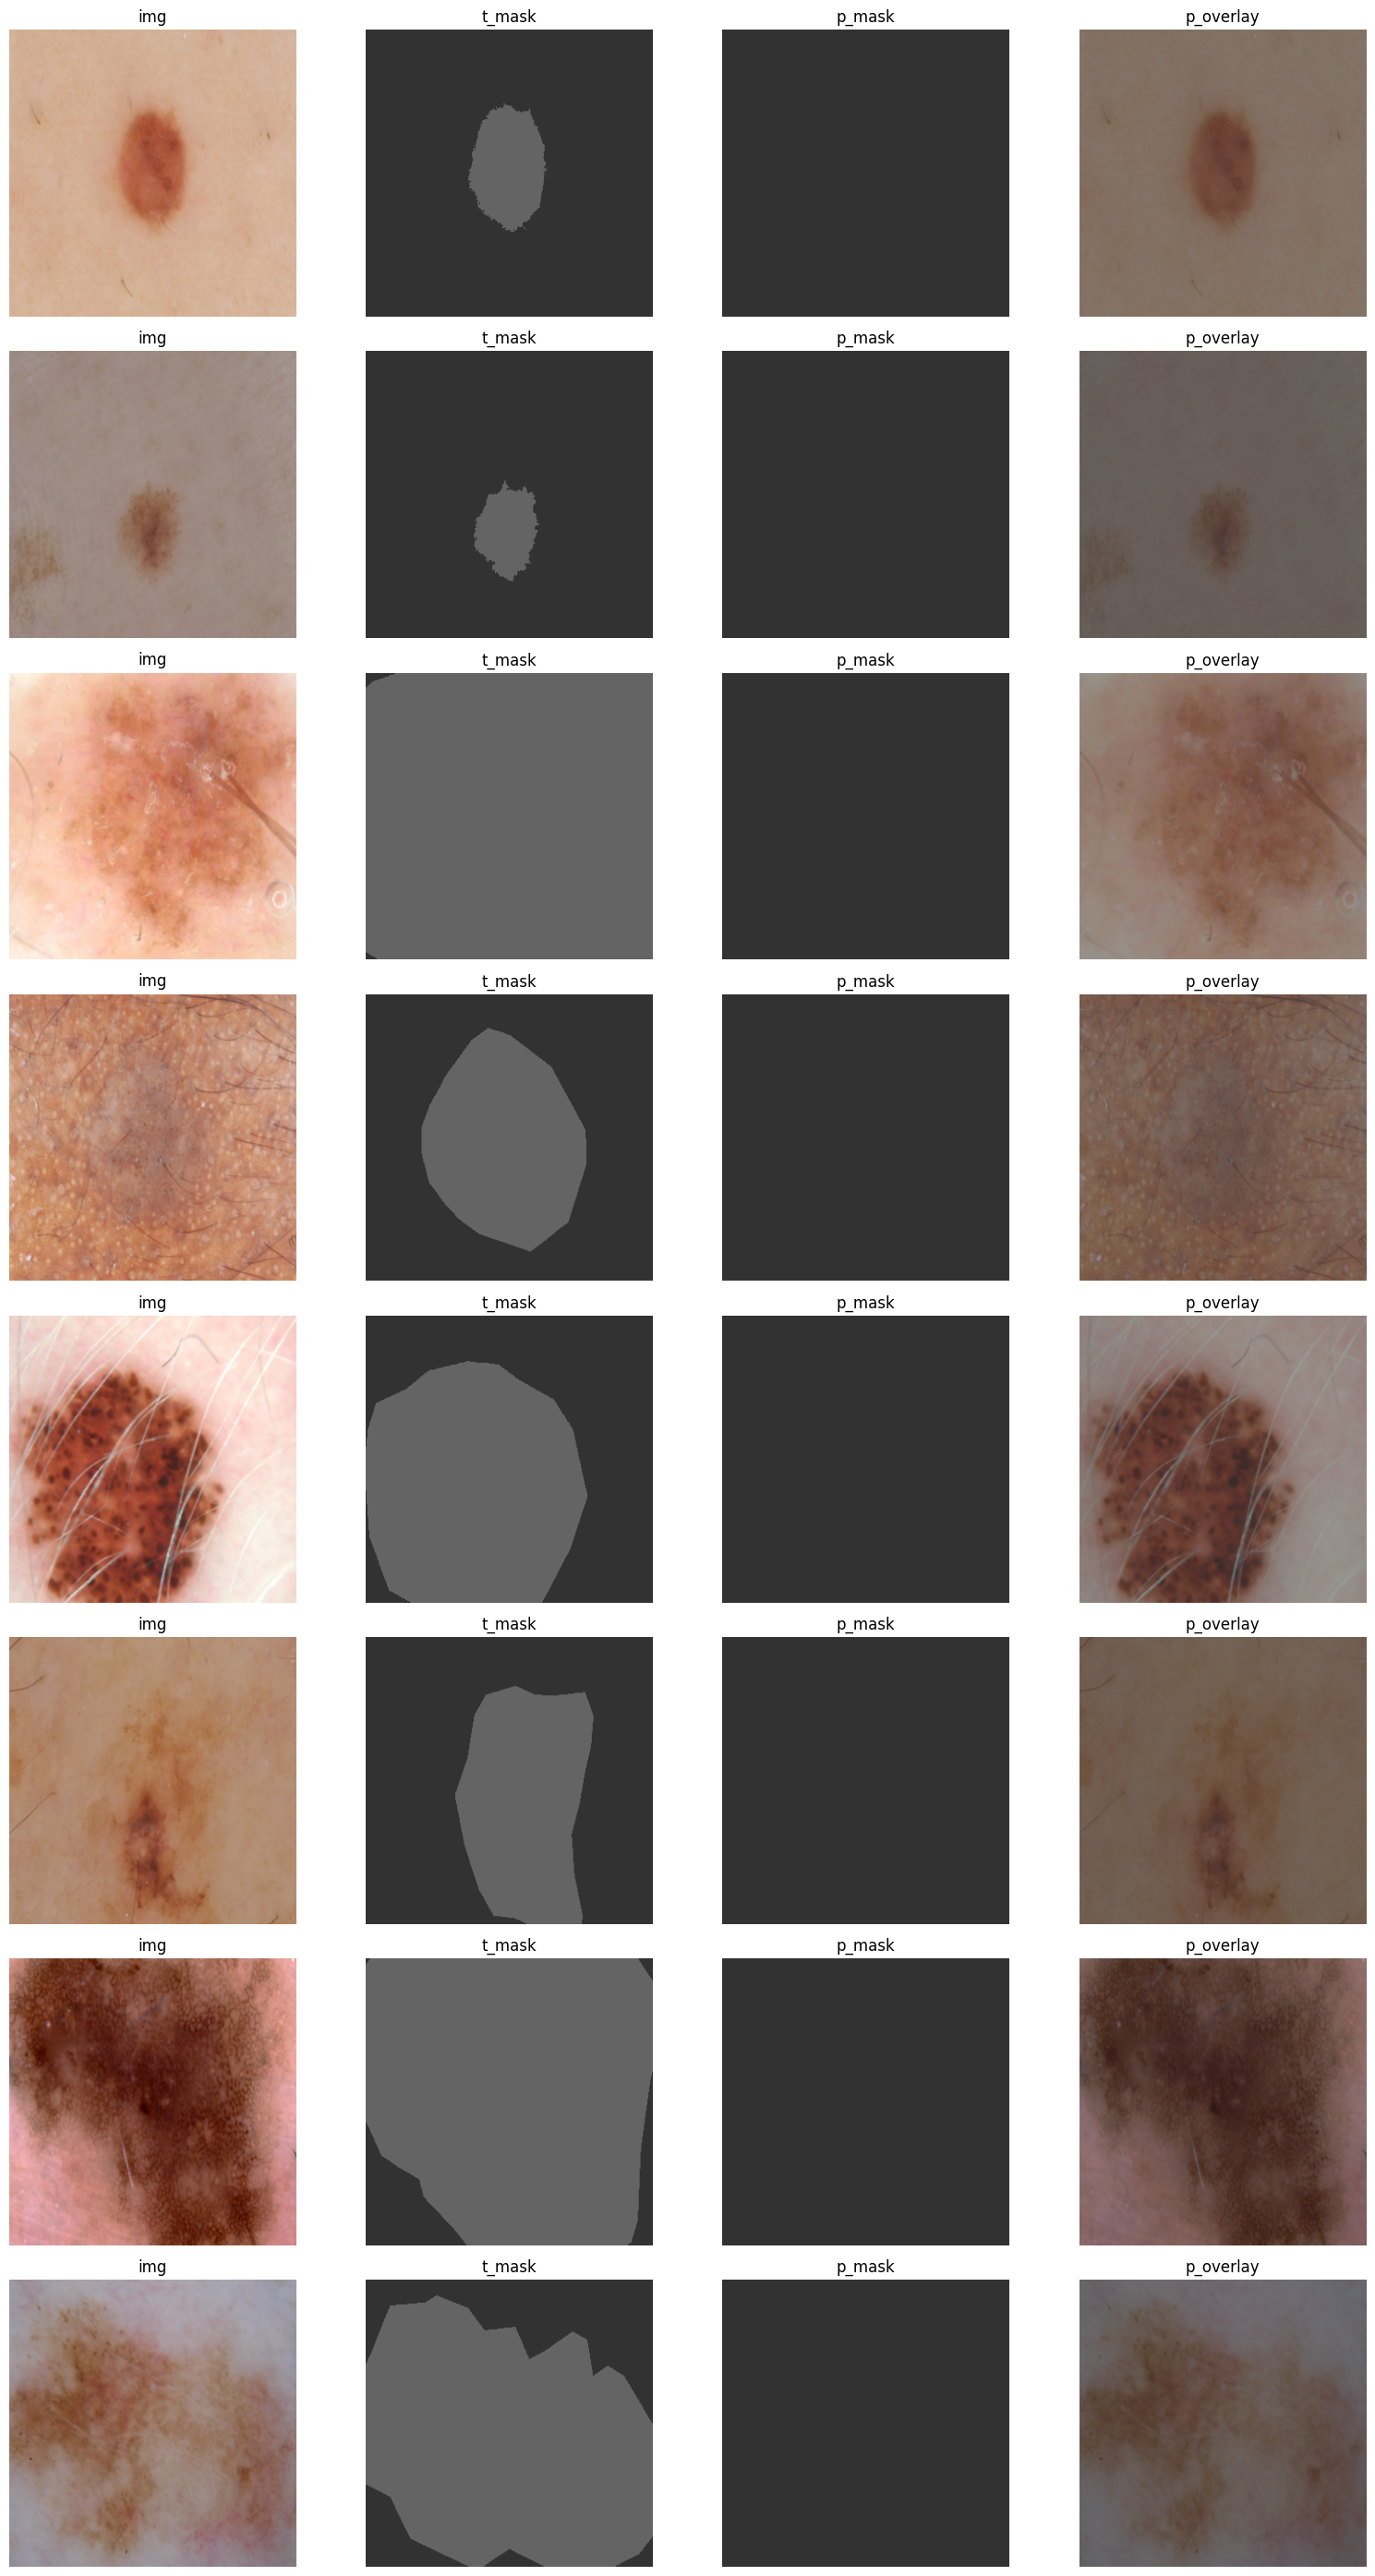

best_m mIoU: 0.5 저장 진행


100%|██████████| 260/260 [12:06<00:00,  2.79s/it]


[Epoch2] tr_loss:0.00038970689822273905 t:726.4776802062988


100%|██████████| 65/65 [03:06<00:00,  2.86s/it]


[Epoch2] mIoU:50.00%


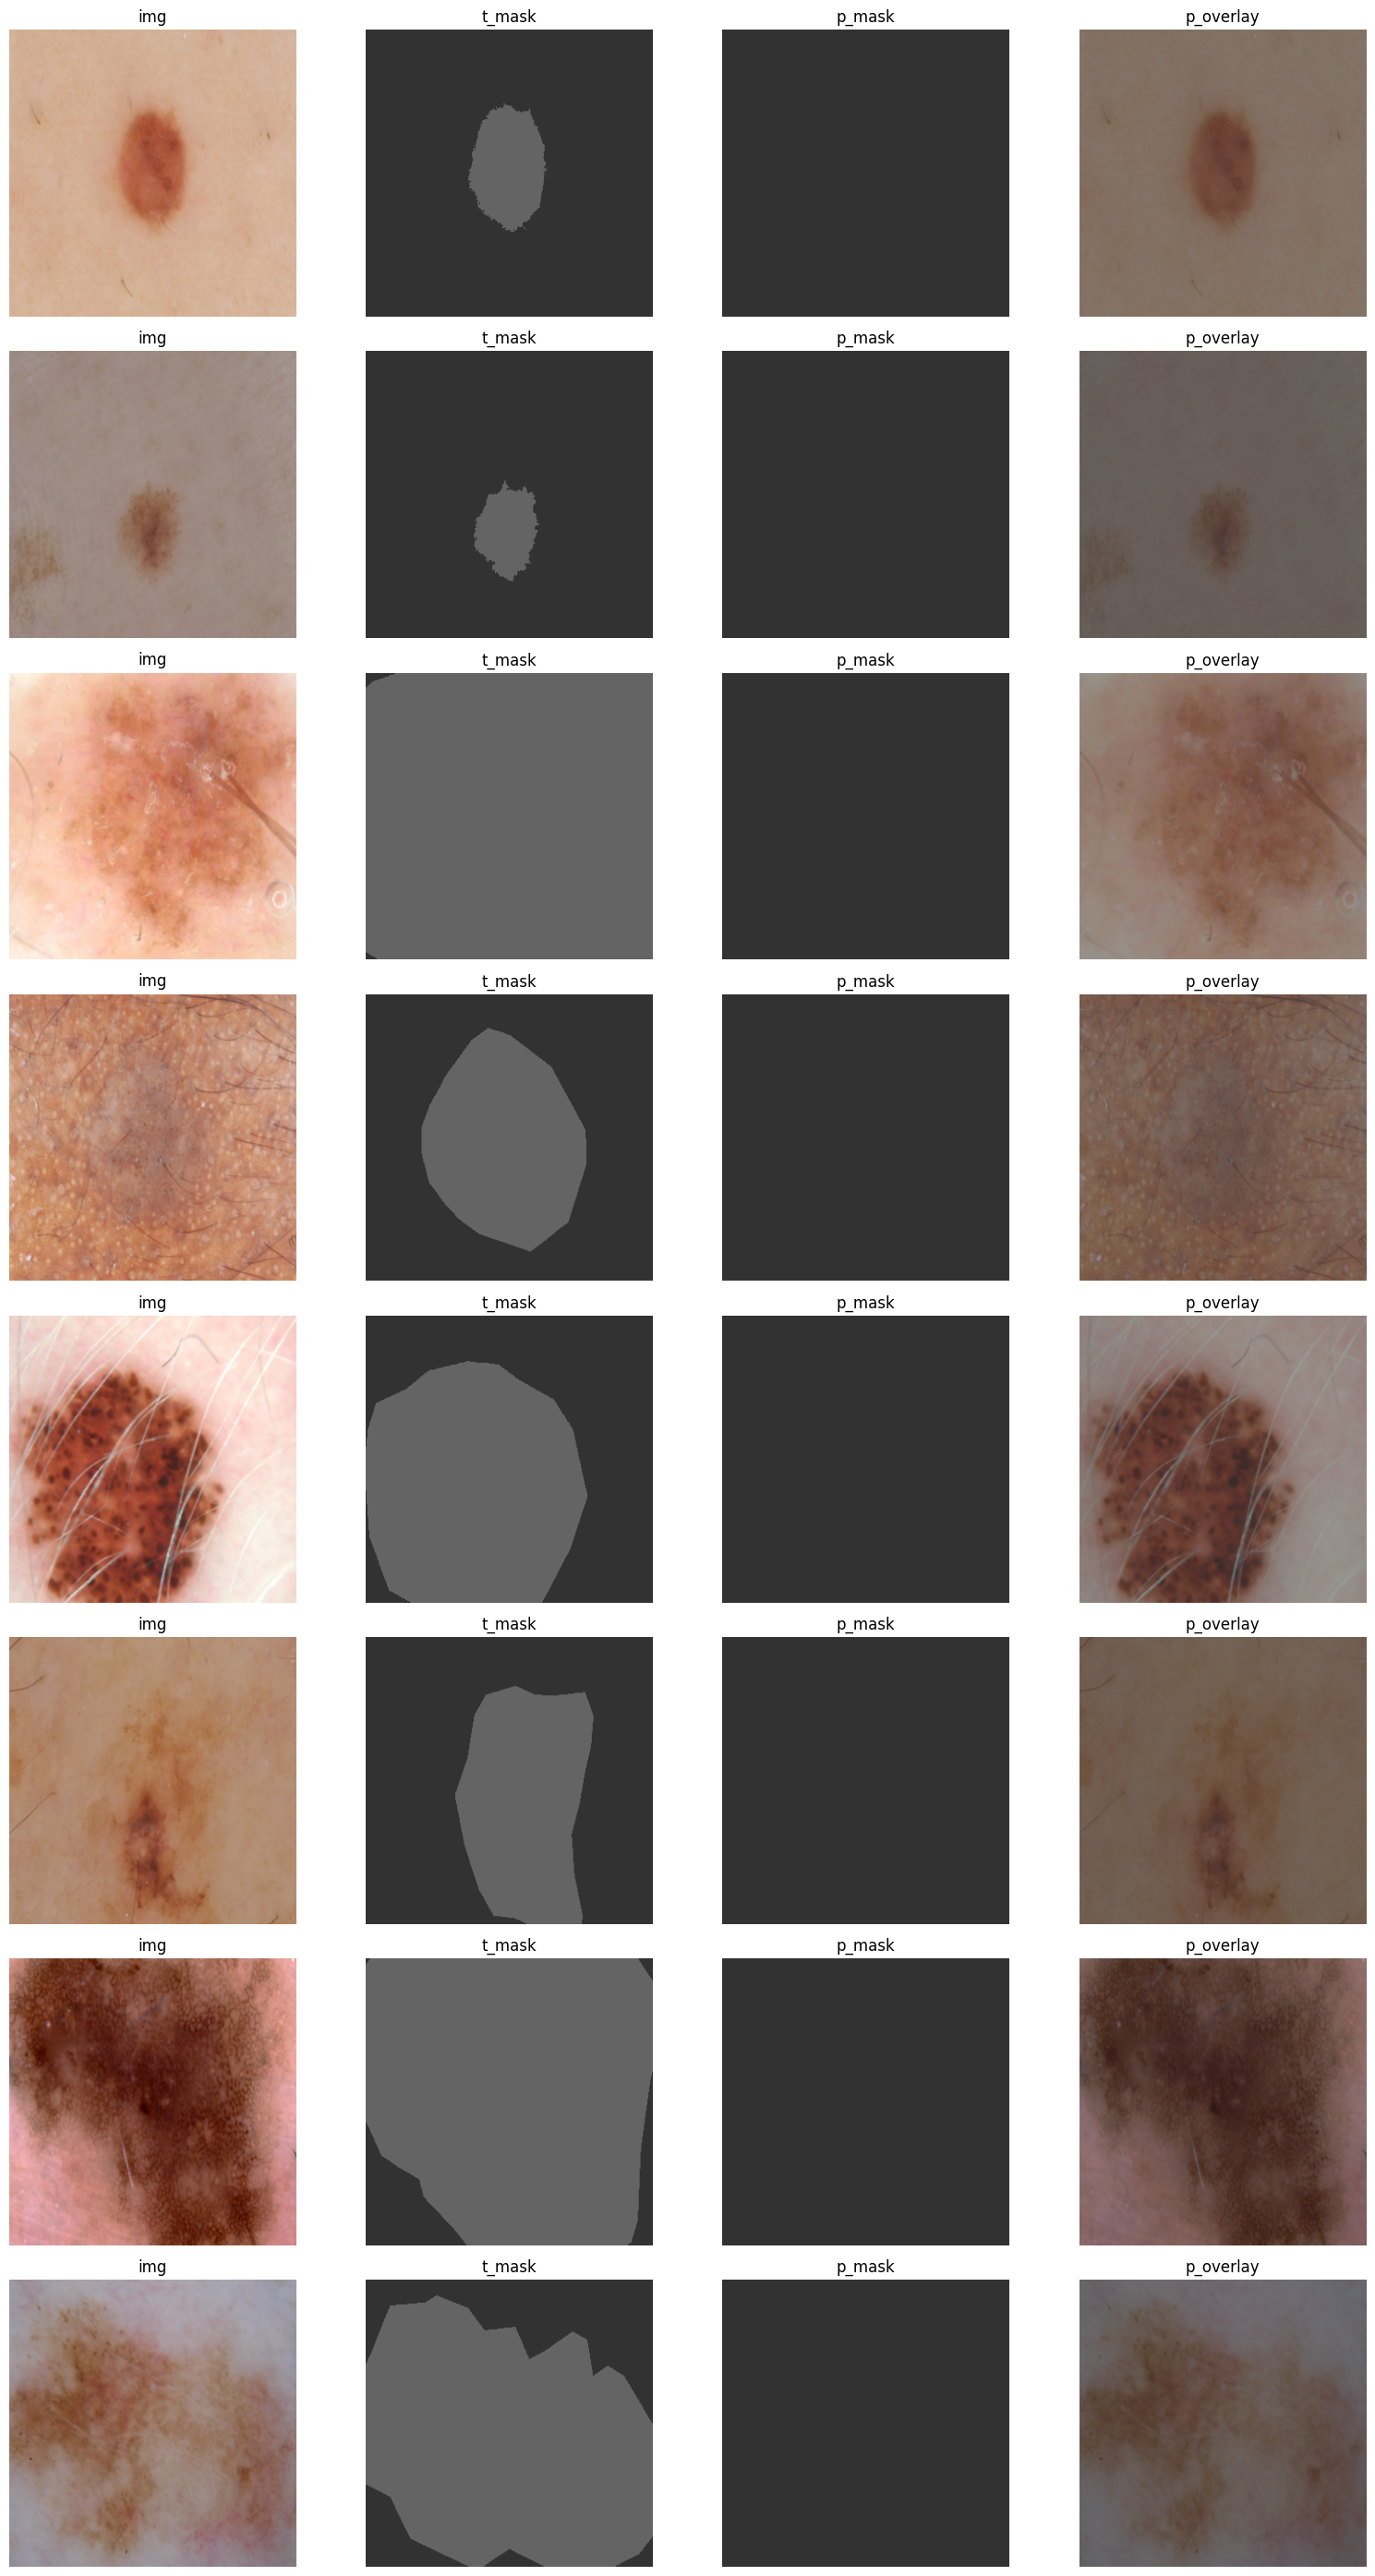

100%|██████████| 260/260 [12:06<00:00,  2.80s/it]


[Epoch3] tr_loss:0.00016835748402454888 t:726.7035164833069


100%|██████████| 65/65 [02:58<00:00,  2.75s/it]


[Epoch3] mIoU:50.00%


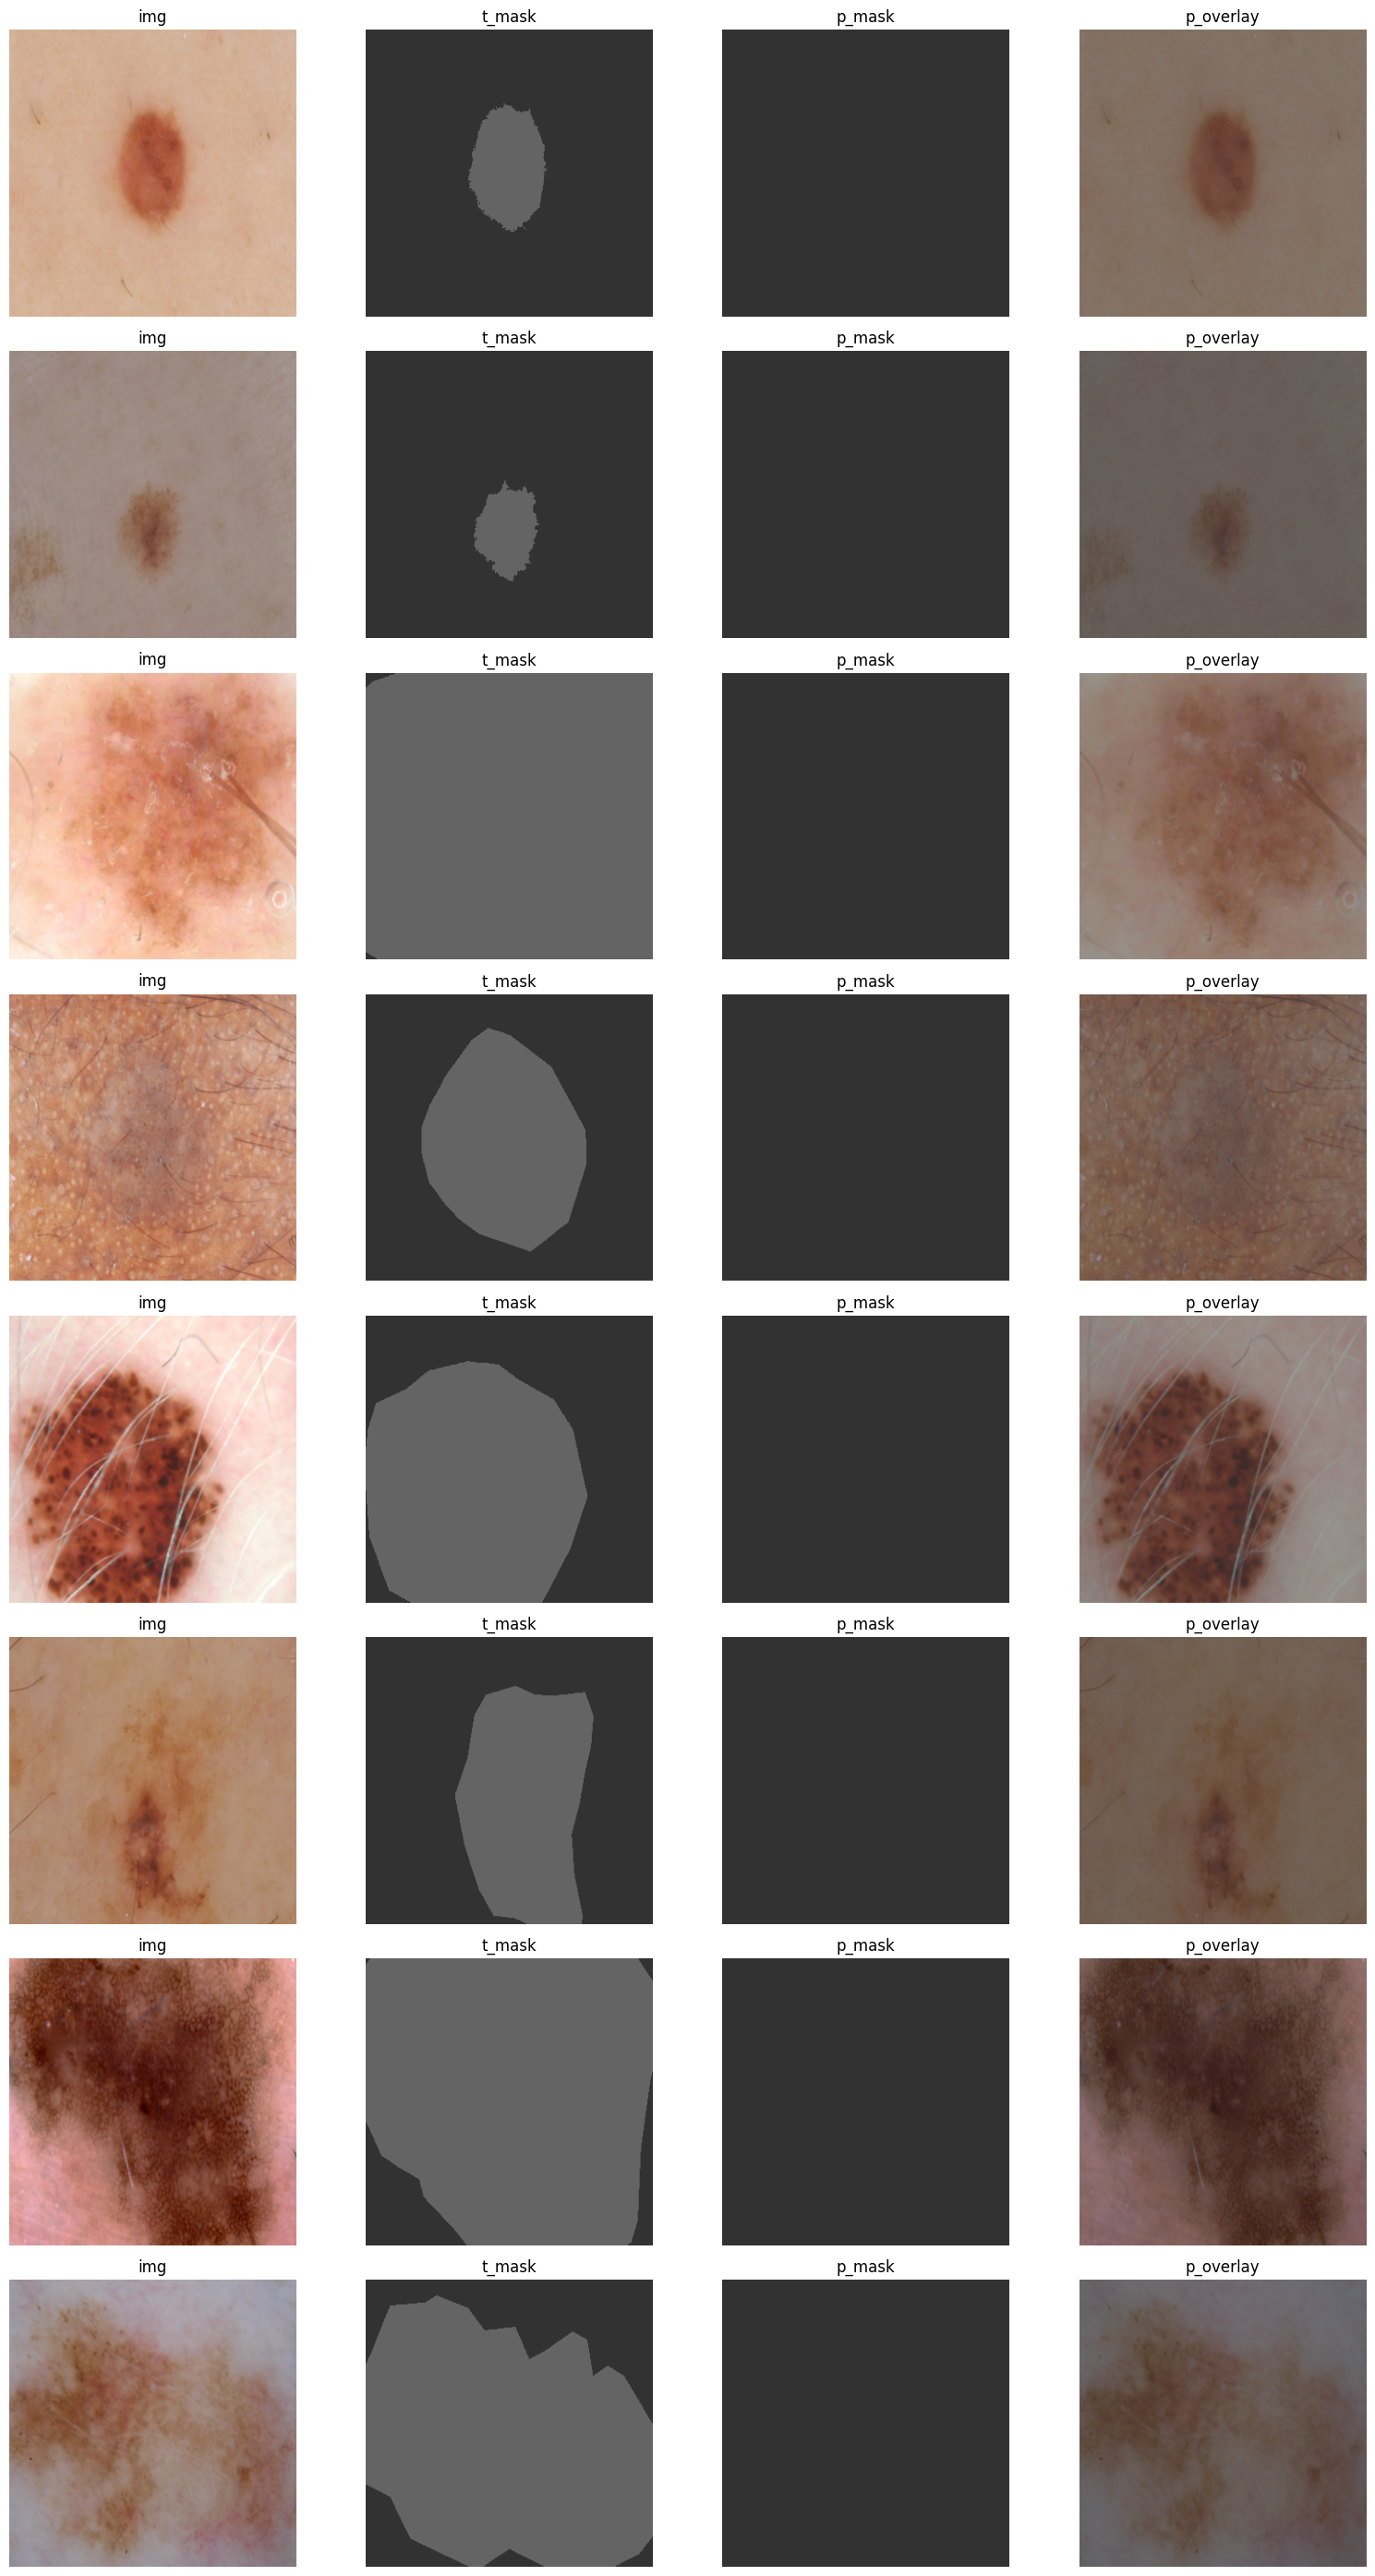

100%|██████████| 260/260 [12:27<00:00,  2.87s/it]


[Epoch4] tr_loss:0.00010969305175104733 t:747.0361716747284


100%|██████████| 260/260 [11:22<00:00,  2.63s/it]


[Epoch5] tr_loss:7.591445643196158e-05 t:682.9905347824097


100%|██████████| 65/65 [02:49<00:00,  2.61s/it]


[Epoch5] mIoU:50.00%


In [ ]:
from tqdm import tqdm
best_miou=-1.0
for ep in range(1,EPOCHS+1):
    train(m,criterion,opt,scaler,tr_ds_loader,DEVICE,ep)
    miou=evaluate(m,val_ds_loader,DEVICE,ep)
    show_samples(m,val_ds_loader,1,0.5,IGNORE_INDEX)

    
    if miou>best_miou:
        best_miou=miou
        torch.save(
            {
                'epoch':ep,
                'model':m.state_dict(),
                'miou':best_miou,
                'config':{'IMG_SIZE':IMG_SIZE,
                          'N_CLASSES':N_CLASSES,
                          "LR":LR,
                          "MOMENTUM":MOMENTUM,
                          "WEIGHT_DECAY":WEIGHT_DECAY
                         }
            },BEST_PATH)
        print(f"best_m mIoU: {best_miou} 저장 진행" )